In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dự đoán trên từng class

In [25]:
import os
import torch
import torch.nn as nn

from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [29]:

# DEVICE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# MODEL
model = models.resnet50(pretrained=False)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 8)

model_path = r'/content/drive/MyDrive/TrainAndTestModel_Classification_natural/natural_resnet50_model2.pth'

state_dict = torch.load(model_path, map_location=device)

# Fix nếu train bằng DataParallel
new_state_dict = {}
for k, v in state_dict.items():
    new_state_dict[k.replace("module.", "")] = v

model.load_state_dict(new_state_dict)

model = model.to(device)
model.eval()

# TRANSFORM
test_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# DATASET
test_folder = r'/content/drive/MyDrive/TrainAndTestModel_Classification_natural/Test_Car_Cat_Dog'

dataset = datasets.ImageFolder(
    root=test_folder,
    transform=test_transforms
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=False
)

# Class names trong folder test
test_classes = dataset.classes
print("Test classes:", test_classes)

# Class index mapping của dataset
dataset_class_to_idx = dataset.class_to_idx

# Class names của model (8 class)
model_classes = [
'airplane','car','cat','dog',
'flower','fruit','motorbike','person'
]

# Mapping dataset label -> model label
label_map = {dataset_class_to_idx[c]: model_classes.index(c) for c in test_classes}

# TEST LOOP
all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in loader:

        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs,1).cpu()

        # convert dataset label -> model label
        labels = torch.tensor([label_map[l.item()] for l in labels])

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())



Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Test classes: ['car', 'cat', 'dog']


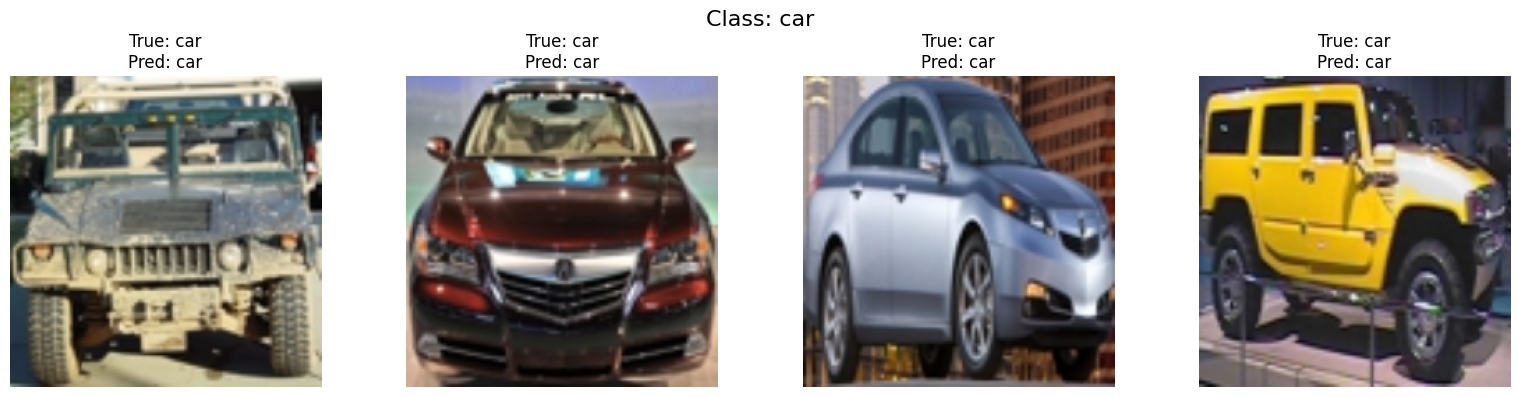

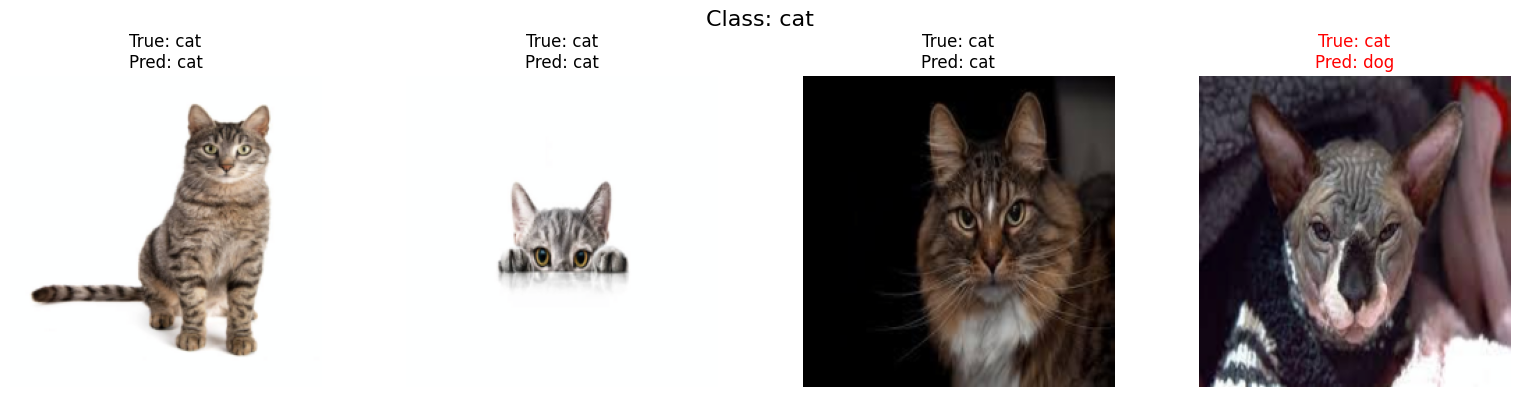

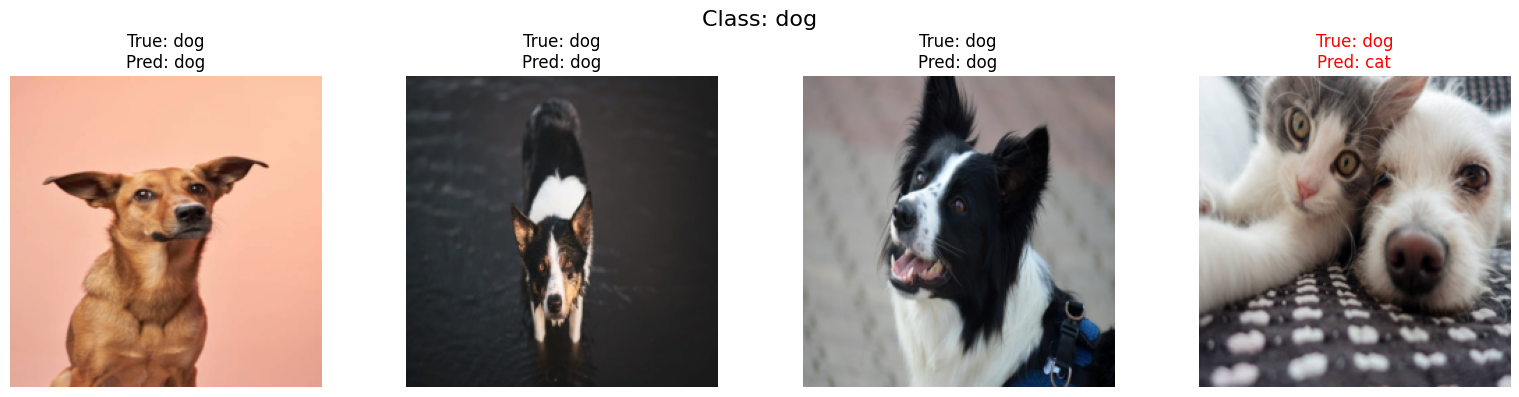

In [30]:
# SHOW 4 IMAGES PER CLASS
num_images = 4

for class_name in test_classes:

    class_idx = dataset_class_to_idx[class_name]

    # lấy index ảnh thuộc class
    indices = [i for i,(path,label) in enumerate(dataset.samples) if label == class_idx][:num_images]

    plt.figure(figsize=(16,4))
    plt.suptitle(f"Class: {class_name}", fontsize=16)

    for i, idx in enumerate(indices):

        img_path, label = dataset.samples[idx]

        img = dataset.loader(img_path)
        img_tensor = test_transforms(img)

        img_np = img_tensor.permute(1,2,0).numpy()

        # unnormalize
        mean=[0.485,0.456,0.406]
        std=[0.229,0.224,0.225]
        img_np = std * img_np + mean
        img_np = img_np.clip(0,1)

        true_label = model_classes[label_map[label]]
        pred_label = model_classes[all_preds[idx]]

        color = "red" if pred_label != true_label else "black"

        plt.subplot(1,4,i+1)
        plt.imshow(img_np)
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


Accuracy: 91.36%


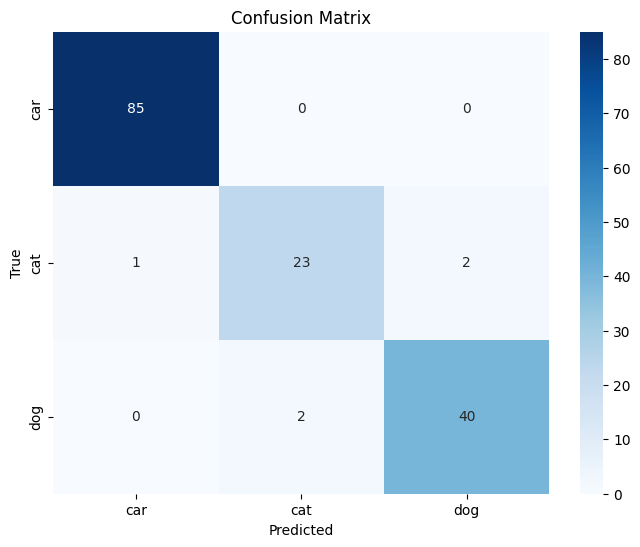


Classification Report:

              precision    recall  f1-score   support

         car       0.99      1.00      0.99        85
         cat       0.92      0.66      0.77        35
         dog       0.95      0.95      0.95        42

   micro avg       0.97      0.91      0.94       162
   macro avg       0.95      0.87      0.90       162
weighted avg       0.96      0.91      0.93       162



In [31]:
# ACCURACY
accuracy = accuracy_score(all_labels, all_preds)

print(f"\nAccuracy: {accuracy*100:.2f}%")

# CONFUSION MATRIX
test_label_indices = [model_classes.index(c) for c in test_classes]

cm = confusion_matrix(
    all_labels,
    all_preds,
    labels=test_label_indices
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=test_classes,
    yticklabels=test_classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# CLASSIFICATION REPORT
print("\nClassification Report:\n")

print(classification_report(
    all_labels,
    all_preds,
    labels=test_label_indices,
    target_names=test_classes,
    zero_division=0
))

Dự đoán trên từng ảnh

In [39]:
# PREDICT AND SHOW IMAGES (4 PER ROW)

import math

predict_folder = r'/content/drive/MyDrive/TrainAndTestModel_Classification_natural/picture_test'

image_files = [f for f in os.listdir(predict_folder)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]

cols = 4
rows = math.ceil(len(image_files) / cols)

plt.figure(figsize=(4*cols,4*rows))

for i, img_name in enumerate(image_files):

    img_path = os.path.join(predict_folder, img_name)

    img = Image.open(img_path).convert("RGB")
    img_tensor = test_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = torch.argmax(output,1).item()

    pred_label = model_classes[pred]

    plt.subplot(rows, cols, i+1)
    plt.imshow(img)
    plt.title(f"Predicted: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.